In [1]:
import os
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
BASE = "/content/drive/MyDrive/DSLab"
os.makedirs(BASE, exist_ok=True)

Mounted at /content/drive


In [2]:
df = pd.read_csv(f"{BASE}/GlobalFindexDatabase2025.csv",low_memory=False)

# keep only aggregate country-level rows
df = df[(df["group"] == "all") & (df["group2"] == "all")]

# candidate variables with better temporal coverage
cols = [
    "countrynewwb",
    "codewb",
    "year",
    "regionwb24_hi",
    "incomegroupwb24",
    "account_t_d",
    "mobileaccount_t_d",
    "borrow_any_t_d",
    "save_any_t_d",
    "fing2p_fin",
    "fing2p_mob"
]

df = df[cols]

print(df.shape)
print(df["year"].value_counts().sort_index())
print(df.isna().sum())


(771, 11)
year
2011    156
2014    154
2017    158
2021    135
2022     16
2024    152
Name: count, dtype: int64
countrynewwb           0
codewb                 0
year                   0
regionwb24_hi         60
incomegroupwb24       60
account_t_d            0
mobileaccount_t_d    411
borrow_any_t_d       206
save_any_t_d         206
fing2p_fin           214
fing2p_mob           214
dtype: int64


In [3]:
print(df["year"].value_counts())
print(df["countrynewwb"].nunique())

year
2017    158
2011    156
2014    154
2024    152
2021    135
2022     16
Name: count, dtype: int64
174


In [4]:
df = df[(df["year"] != 2022) & (df["year"] != 2011)]

In [5]:
df.to_csv(f"{BASE}/Findex_clean.csv", index=False)

In [6]:
df.isna().mean().sort_values(ascending=False)

,0
mobileaccount_t_d,0.422371
fing2p_mob,0.096828
fing2p_fin,0.096828
borrow_any_t_d,0.083472
save_any_t_d,0.083472
incomegroupwb24,0.080134
regionwb24_hi,0.080134
year,0.000000
codewb,0.000000
countrynewwb,0.000000


In [7]:
# fill missing values
df_filled = df.copy()

cols = [
'account_t_d',
'mobileaccount_t_d',
'borrow_any_t_d',
'save_any_t_d',
'fing2p_fin',
'fing2p_mob'
]

df_filled[cols] = df_filled.groupby("year")[cols].transform(
    lambda x: x.fillna(x.mean())
)

In [8]:
# fill non-critical categorical missing values
df_filled["regionwb24_hi"] = df_filled["regionwb24_hi"].fillna("Unknown")
df_filled["incomegroupwb24"] = df_filled["incomegroupwb24"].fillna("Unknown")

# final check
print(df.shape)
print(df.isna().sum())

(599, 11)
countrynewwb           0
codewb                 0
year                   0
regionwb24_hi         48
incomegroupwb24       48
account_t_d            0
mobileaccount_t_d    253
borrow_any_t_d        50
save_any_t_d          50
fing2p_fin            58
fing2p_mob            58
dtype: int64


In [9]:
# dataset ready for analysis
df_filled.to_csv(f"{BASE}/Findex_prepared.csv", index=False)

In [10]:
df = pd.read_csv(f"{BASE}/Findex_prepared.csv")
print(df.shape)
df.head()

(599, 11)


,countrynewwb,codewb,year,regionwb24_hi,incomegroupwb24,account_t_d,mobileaccount_t_d,borrow_any_t_d,save_any_t_d,fing2p_fin,fing2p_mob
0,Afghanistan,AFG,2014,South Asia (excluding high income),Low income,0.099610,0.003044,0.348615,0.257693,0.022514,0.000000
1,Albania,ALB,2014,Europe & Central Asia (excluding high income),Upper middle income,0.379864,0.059658,0.567802,0.383738,0.096383,0.000000
2,Algeria,DZA,2014,Middle East & North Africa (excluding high inc...,Lower middle income,0.504758,0.059658,0.257866,0.453138,0.151797,0.004671
3,Angola,AGO,2014,Sub-Saharan Africa (excluding high income),Lower middle income,0.293181,0.059658,0.308385,0.530579,0.118506,0.000000
4,Argentina,ARG,2014,Latin America & Caribbean (excluding high income),Upper middle income,0.501973,0.004323,0.337042,0.231396,0.139557,0.000000


In [11]:
from sklearn.preprocessing import MinMaxScaler

vars_index = [
'account_t_d',
'mobileaccount_t_d',
'borrow_any_t_d',
'save_any_t_d',
'fing2p_fin',
'fing2p_mob'
]

scaler = MinMaxScaler()

df_norm = df.copy()
df_norm[vars_index] = scaler.fit_transform(df[vars_index])

In [12]:
df_norm["FII"] = df_norm[vars_index].mean(axis=1)

In [13]:
ranking_2024 = (
    df_norm[df_norm["year"] == 2024]
    .sort_values("FII", ascending=False)
)

ranking_2024[["countrynewwb","FII"]].head(15)

,countrynewwb,FII
497,Mongolia,0.647584
476,Kenya,0.635347
540,Uganda,0.598858
521,Senegal,0.596049
458,Ghana,0.587111
549,Zambia,0.536098
426,Brazil,0.524599
535,Thailand,0.522980
475,Kazakhstan,0.520506
441,Croatia,0.518793


In [14]:
ranking_2024[["countrynewwb","FII"]].tail(15)

,countrynewwb,FII
486,Libya,0.264806
412,Algeria,0.253375
447,"Egypt, Arab Rep.",0.250082
499,Morocco,0.248602
511,Pakistan,0.244463
488,Madagascar,0.243664
462,Honduras,0.238353
506,Niger,0.231872
538,Tunisia,0.227814
481,Lao PDR,0.220731


In [15]:
region_analysis = (
    df_norm
    .groupby(["regionwb24_hi","year"])["FII"]
    .mean()
    .reset_index()
)

region_analysis.head()

,regionwb24_hi,year,FII
0,East Asia & Pacific (excluding high income),2014,0.310736
1,East Asia & Pacific (excluding high income),2017,0.290885
2,East Asia & Pacific (excluding high income),2021,0.405972
3,East Asia & Pacific (excluding high income),2024,0.415174
4,Europe & Central Asia (excluding high income),2014,0.209450


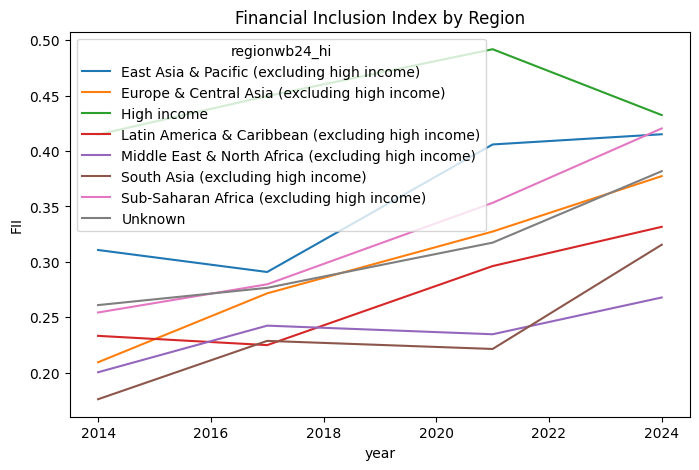

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.lineplot(data=region_analysis, x="year", y="FII", hue="regionwb24_hi")
plt.title("Financial Inclusion Index by Region")
plt.show()

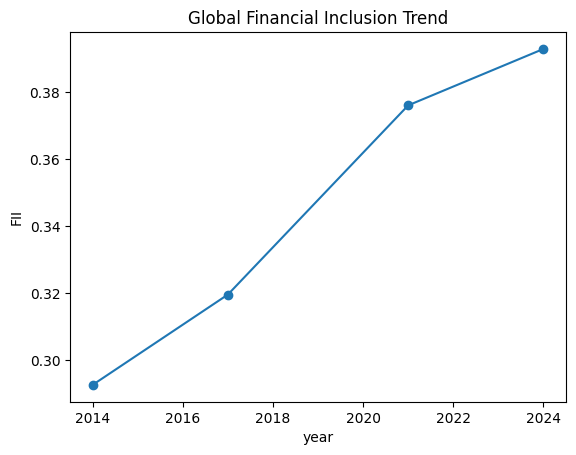

In [17]:
trend = df_norm.groupby("year")["FII"].mean()

trend.plot(marker="o")
plt.title("Global Financial Inclusion Trend")
plt.ylabel("FII")
plt.show()

In [18]:
df_norm.to_csv(f"{BASE}/Findex_with_index.csv", index=False)

In [19]:
df.columns

Index(['countrynewwb', 'codewb', 'year', 'regionwb24_hi', 'incomegroupwb24',
       'account_t_d', 'mobileaccount_t_d', 'borrow_any_t_d', 'save_any_t_d',
       'fing2p_fin', 'fing2p_mob'],
      dtype='object')

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


vars_index = [
'account_t_d',
'mobileaccount_t_d',
'borrow_any_t_d',
'save_any_t_d',
'fing2p_fin',
'fing2p_mob'
]

X = df[vars_index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=1)
df["FII_PCA"] = pca.fit_transform(X_scaled)

In [21]:
print(pca.explained_variance_ratio_)

[0.43228599]


In [22]:
weights = pd.Series(pca.components_[0], index=vars_index)
print(weights.sort_values(ascending=False))

account_t_d          0.509618
save_any_t_d         0.450784
fing2p_fin           0.441327
borrow_any_t_d       0.388613
mobileaccount_t_d    0.335931
fing2p_mob           0.280081
dtype: float64


In [23]:
df["FII_equal"] = df[vars_index].mean(axis=1)

In [24]:
print(df[["FII_equal", "FII_PCA"]].corr())

           FII_equal   FII_PCA
FII_equal   1.000000  0.992315
FII_PCA     0.992315  1.000000


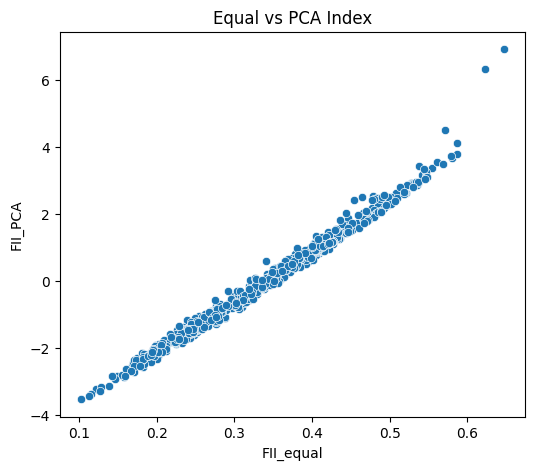

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="FII_equal", y="FII_PCA")
plt.title("Equal vs PCA Index")
plt.show()

In [26]:
rank_equal = df[df["year"] == 2024].sort_values("FII_equal", ascending=False)
rank_pca = df[df["year"] == 2024].sort_values("FII_PCA", ascending=False)

print(rank_equal[["countrynewwb","FII_equal"]].head(10))
print(rank_pca[["countrynewwb","FII_PCA"]].head(10))

    countrynewwb  FII_equal
476        Kenya   0.579591
497     Mongolia   0.570997
458        Ghana   0.544894
540       Uganda   0.543770
521      Senegal   0.538271
549       Zambia   0.492289
535     Thailand   0.489574
441      Croatia   0.488069
426       Brazil   0.483628
475   Kazakhstan   0.480195
      countrynewwb   FII_PCA
497       Mongolia  4.495426
476          Kenya  3.715019
521        Senegal  3.438612
540         Uganda  3.349927
458          Ghana  3.033882
549         Zambia  2.569322
535       Thailand  2.512047
546  Venezuela, RB  2.495548
426         Brazil  2.462358
475     Kazakhstan  2.453104


In [27]:
df["diff"] = df["FII_PCA"] - df["FII_equal"]

df[df["year"] == 2024].sort_values("diff", ascending=False).head(10)

,countrynewwb,codewb,year,regionwb24_hi,incomegroupwb24,account_t_d,mobileaccount_t_d,borrow_any_t_d,save_any_t_d,fing2p_fin,fing2p_mob,FII_PCA,FII_equal,diff
497,Mongolia,MNG,2024,East Asia & Pacific (excluding high income),Lower middle income,0.982787,0.640304,0.683359,0.479117,0.390056,0.250358,4.495426,0.570997,3.924429
476,Kenya,KEN,2024,Sub-Saharan Africa (excluding high income),Lower middle income,0.901199,0.874994,0.818840,0.701942,0.101508,0.079062,3.715019,0.579591,3.135428
521,Senegal,SEN,2024,Sub-Saharan Africa (excluding high income),Lower middle income,0.764609,0.669126,0.818580,0.777029,0.084739,0.115541,3.438612,0.538271,2.900342
540,Uganda,UGA,2024,Sub-Saharan Africa (excluding high income),Low income,0.728274,0.677383,0.902139,0.834059,0.049260,0.071508,3.349927,0.543770,2.806157
458,Ghana,GHA,2024,Sub-Saharan Africa (excluding high income),Lower middle income,0.812430,0.782814,0.742407,0.820131,0.075751,0.035829,3.033882,0.544894,2.488988
549,Zambia,ZMB,2024,Sub-Saharan Africa (excluding high income),Low income,0.727024,0.693108,0.701479,0.683998,0.051491,0.096632,2.569322,0.492289,2.077034
546,"Venezuela, RB",VEN,2024,Latin America & Caribbean (excluding high income),Upper middle income,0.873185,0.337397,0.620719,0.520095,0.273829,0.159184,2.495548,0.464068,2.031480
535,Thailand,THA,2024,East Asia & Pacific (excluding high income),Upper middle income,0.918250,0.416774,0.490933,0.630886,0.385770,0.094831,2.512047,0.489574,2.022473
426,Brazil,BRA,2024,Latin America & Caribbean (excluding high income),Upper middle income,0.863812,0.581666,0.636074,0.467473,0.239643,0.113100,2.462358,0.483628,1.978730
475,Kazakhstan,KAZ,2024,Europe & Central Asia (excluding high income),Upper middle income,0.870486,0.488575,0.628287,0.529591,0.250944,0.113284,2.453104,0.480195,1.972910


In [28]:
gdp = pd.read_csv(f"{BASE}/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv", skiprows=4)

In [29]:
gdp = gdp[["Country Code", "2014", "2017", "2021", "2024"]]

In [30]:
# Reshape
gdp_long = gdp.melt(
    id_vars=["Country Code"],
    var_name="year",
    value_name="GDP_per_capita"
)

In [31]:
gdp_long.rename(columns={"Country Code": "codewb"}, inplace=True)

In [32]:
gdp_long["year"] = gdp_long["year"].astype(int)

In [33]:
gdp_long.head()

,codewb,year,GDP_per_capita
0,ABW,2014,26129.839062
1,AFE,2014,1690.166792
2,AFG,2014,625.054942
3,AFW,2014,2221.350338
4,AGO,2014,5649.687625
